# 🍯🌡️ The viscous background, measured at three temperatures — HB vs TC on Carbopol in glycerin

*The same workflow as the [rheofit case study](https://rheofit.readthedocs.io/en/latest/walkthrough-carbopol-glycerin.html), run live in JupyterLite. Three flow curves of Carbopol in glycerin (20/30/40 °C) are fit with **Herschel–Bulkley** and the **three-component (TC)** model; TC's background viscosity η_bg(T) is then held up against the literature Arrhenius law for pure glycerol.*

**Run each cell in order** (▶). The first cell installs `rheofit` in your browser — no server involved.

In [7]:
%pip install -q rheofit rheopy-rheodata


Note: you may need to restart the kernel to use updated packages.


c:\Users\caggioni.m\rheolite\.venv\Scripts\python.exe: No module named pip


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import rheodata
import rheofit

rheofit_version = getattr(rheofit, "__version__", "installed")
rheodata_version = getattr(rheodata, "__version__", "installed")
print(f"rheofit {rheofit_version}")
print(f"rheodata {rheodata_version}")

rheofit 1.1.0
rheodata installed


## 🧪 The dataset

The [rheodata](https://github.com/rheopy/rheodata) library (`caggioni_carbopol_glycerin_temp`) holds equilibrium flow curves of Carbopol in glycerin — 51 points each, 0.001 to 100 s⁻¹ — at 20, 30 and 40 °C (the 50 °C sweep is excluded, just like the published case study).

In [9]:
temperatures_celsius = (40, 30, 20)
sample_ids_by_temperature = {
    40: "T_40",
    30: "T_30",
    20: "T_20",
}
flow_curves_by_temperature = {}

for temperature_celsius in temperatures_celsius:
    sample_id = sample_ids_by_temperature[temperature_celsius]
    flow_curve = rheodata.to_rheofit(
        "caggioni_carbopol_glycerin_temp",
        sample_id,
    )
    flow_curves_by_temperature[temperature_celsius] = flow_curve
    print(f"{temperature_celsius} °C: {len(flow_curve)} points")

shear_rate = flow_curves_by_temperature[20]["Shear rate / 1/s"].to_numpy()
stress_by_temperature = {
    temperature_celsius: flow_curve["Stress / Pa"].to_numpy()
    for temperature_celsius, flow_curve in flow_curves_by_temperature.items()
}

40 °C: 51 points
30 °C: 51 points
20 °C: 51 points


## 🥊 Head-to-head: HB vs TC at every temperature

Six fits — HB and TC at 20, 30 and 40 °C, `effort="thorough"`, `seed=0`. ⏳ *This takes a few minutes in the browser.*

In [10]:
fits_by_temperature = {}
for temperature_celsius in temperatures_celsius:
    flow_curve = flow_curves_by_temperature[temperature_celsius]
    herschel_bulkley_fit = rheofit.fit(
        flow_curve,
        "herschel_bulkley",
        effort="thorough",
        seed=0,
    )
    tc_fit = rheofit.fit(
        flow_curve,
        "tc",
        effort="thorough",
        seed=0,
    )
    fits_by_temperature[temperature_celsius] = {
        "herschel_bulkley": herschel_bulkley_fit,
        "tc": tc_fit,
    }
    print(
        f"T={temperature_celsius} °C  "
        f"HB RedChi2={herschel_bulkley_fit['redchi']:.3e}  "
        f"TC RedChi2={tc_fit['redchi']:.3e}"
    )


def format_parameter_estimate(estimate):
    relative_error_pct = 100 * estimate["stderr"] / estimate["value"]
    return f"{estimate['value']:8.4g} ± {relative_error_pct:4.1f}%"


print()
print(
    f"{'T (°C)':>6} | {'HB RedChi²':>10} | {'TC RedChi²':>10} | "
    f"{'σ_y / Pa':>16} | {'γ̇_c / 1/s':>16} | {'η_bg / Pa·s':>16}"
)
print("-" * 94)

for temperature_celsius in temperatures_celsius:
    fits = fits_by_temperature[temperature_celsius]
    herschel_bulkley_fit = fits["herschel_bulkley"]
    tc_fit = fits["tc"]
    tc_parameters = tc_fit["params"]

    print(
        f"{temperature_celsius:>6} | "
        f"{herschel_bulkley_fit['redchi']:>10.2e} | "
        f"{tc_fit['redchi']:>10.2e} | "
        f"{format_parameter_estimate(tc_parameters['sigma_y']):>16} | "
        f"{format_parameter_estimate(tc_parameters['gamma_dot_c']):>16} | "
        f"{format_parameter_estimate(tc_parameters['eta_bg']):>16}"
    )

T=40 °C  HB RedChi2=4.203e-04  TC RedChi2=1.220e-04
T=30 °C  HB RedChi2=5.854e-04  TC RedChi2=2.046e-04
T=20 °C  HB RedChi2=6.120e-04  TC RedChi2=1.424e-04

T (°C) | HB RedChi² | TC RedChi² |         σ_y / Pa |       γ̇_c / 1/s |      η_bg / Pa·s
----------------------------------------------------------------------------------------------
    40 |   4.20e-04 |   1.22e-04 |    5.358 ±  0.5% |  0.01564 ±  1.6% |   0.6629 ±  5.6%
    30 |   5.85e-04 |   2.05e-04 |    6.314 ±  0.7% |  0.00956 ±  2.1% |     1.06 ±  6.7%
    20 |   6.12e-04 |   1.42e-04 |    7.494 ±  0.7% | 0.005642 ±  1.9% |    2.169 ±  4.3%


## 📉 Flow curves with TC fits

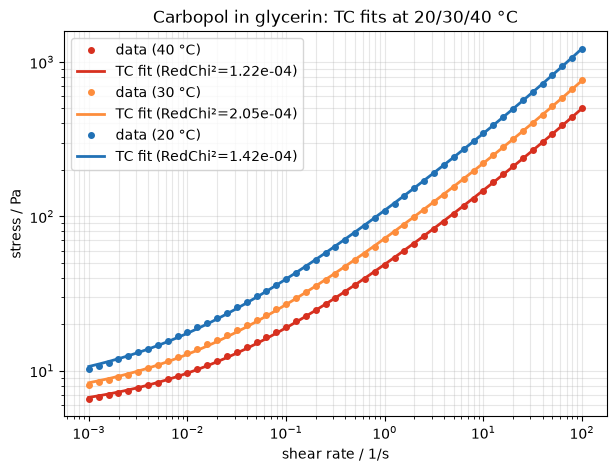

In [11]:
def tc_stress(shear_rate, yield_stress, critical_shear_rate, background_viscosity):
    elastic_stress = yield_stress
    plastic_stress = yield_stress * np.sqrt(shear_rate / critical_shear_rate)
    viscous_stress = background_viscosity * shear_rate
    return elastic_stress + plastic_stress + viscous_stress


plot_colors_by_temperature = {
    40: "#d7301f",
    30: "#fd8d3c",
    20: "#2171b5",
}
shear_rate_grid = np.logspace(-3, 2, 400)

fig, ax_stress = plt.subplots(figsize=(7, 5))
for temperature_celsius in temperatures_celsius:
    tc_fit = fits_by_temperature[temperature_celsius]["tc"]
    tc_parameters = {
        name: estimate["value"]
        for name, estimate in tc_fit["params"].items()
    }
    color = plot_colors_by_temperature[temperature_celsius]

    ax_stress.loglog(
        shear_rate,
        stress_by_temperature[temperature_celsius],
        "o",
        ms=4,
        color=color,
        label=f"data ({temperature_celsius} °C)",
    )
    ax_stress.loglog(
        shear_rate_grid,
        tc_stress(
            shear_rate_grid,
            tc_parameters["sigma_y"],
            tc_parameters["gamma_dot_c"],
            tc_parameters["eta_bg"],
        ),
        "-",
        lw=2,
        color=color,
        label=f"TC fit (RedChi²={tc_fit['redchi']:.2e})",
    )

ax_stress.set_xlabel("shear rate / 1/s")
ax_stress.set_ylabel("stress / Pa")
ax_stress.set_title("Carbopol in glycerin: TC fits at 20/30/40 °C")
ax_stress.legend()
ax_stress.grid(True, which="both", alpha=0.3)
plt.show()

## 📈 Every TC parameter trends the physical way

- **σ_y grows on cooling** (5.36 → 7.49 Pa): the microgel network strengthens.
- **γ̇_c falls on cooling** (0.0156 → 0.0056 s⁻¹): the plastic √γ̇ term takes over at progressively lower shear rates as the background thickens.
- **η_bg thickens on cooling** (0.66 → 2.17 Pa·s): the background viscosity itself is strongly temperature-dependent — exactly what you expect if it is the solvent.

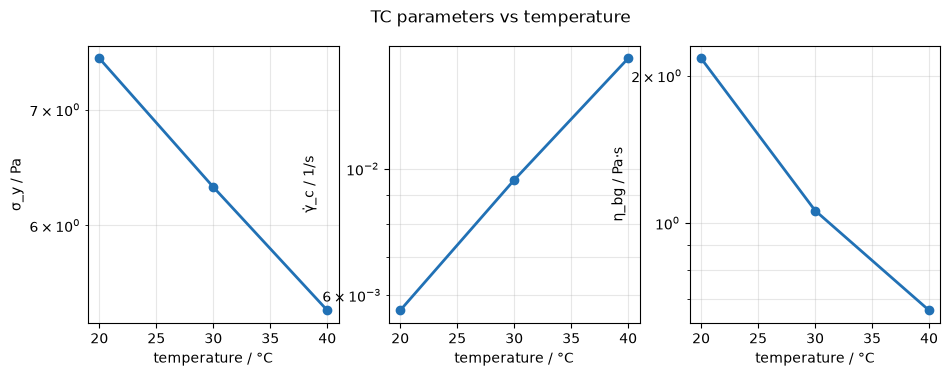

In [12]:
tc_parameter_names = ("sigma_y", "gamma_dot_c", "eta_bg")
tc_parameter_labels = ("σ_y / Pa", "γ̇_c / 1/s", "η_bg / Pa·s")
tc_parameters_by_name = {
    parameter_name: np.array(
        [
            fits_by_temperature[temperature_celsius]["tc"]["params"][parameter_name]["value"]
            for temperature_celsius in temperatures_celsius
        ]
    )
    for parameter_name in tc_parameter_names
}

fig, parameter_axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(11, 3.6),
    sharex=True,
)
for axis, parameter_name, parameter_label in zip(
    parameter_axes,
    tc_parameter_names,
    tc_parameter_labels,
):
    axis.semilogy(
        temperatures_celsius,
        tc_parameters_by_name[parameter_name],
        "o-",
        color="#2171b5",
        lw=2,
    )
    axis.set_xlabel("temperature / °C")
    axis.set_ylabel(parameter_label)
    axis.grid(True, which="both", alpha=0.3)

fig.suptitle("TC parameters vs temperature")
plt.show()

## 🌡️ The Arrhenius test

If η_bg really is the continuous phase (plus whatever the microgel adds at high shear), it should follow the solvent's temperature law: ln η = ln A + E_a/(R·T). Literature glycerol data (Segur & Oberstar 1951: 1.412, 0.612, 0.284 Pa·s at 20/30/40 °C) give E_a = 61.2 kJ/mol — a textbook straight line.

TC η_bg:    E_a = 45.3 kJ/mol, R² = 0.9900
literature: E_a = 61.2 kJ/mol, R² = 1.0000
η_bg / η_glycerol: 2.33, 1.73, 1.54


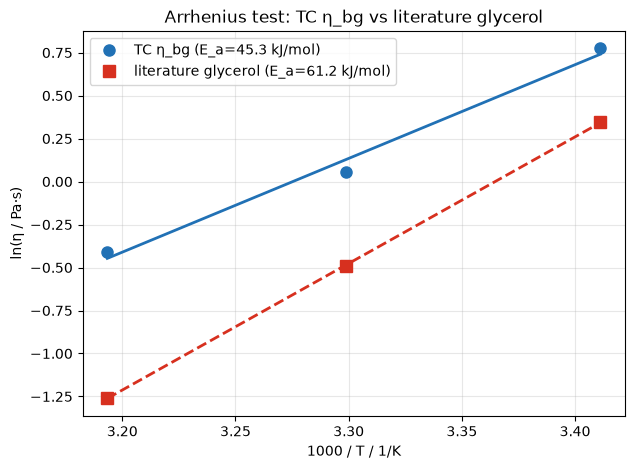

In [13]:
gas_constant_j_per_mol_kelvin = 8.314
temperature_kelvin = np.asarray(temperatures_celsius) + 273.15
inverse_temperature_per_kelvin = 1 / temperature_kelvin

background_viscosity = tc_parameters_by_name["eta_bg"]
glycerol_viscosity = np.array([0.284, 0.612, 1.412])
background_log_viscosity = np.log(background_viscosity)
glycerol_log_viscosity = np.log(glycerol_viscosity)

background_slope, background_intercept = np.polyfit(
    inverse_temperature_per_kelvin,
    background_log_viscosity,
    1,
)
activation_energy_background_kj_per_mol = (
    background_slope * gas_constant_j_per_mol_kelvin / 1000
)
fitted_background_log_viscosity = (
    background_slope * inverse_temperature_per_kelvin
    + background_intercept
)
residual_sum_squares = np.sum(
    (background_log_viscosity - fitted_background_log_viscosity) ** 2
)
total_sum_squares = np.sum(
    (background_log_viscosity - background_log_viscosity.mean()) ** 2
)
coefficient_of_determination = 1 - residual_sum_squares / total_sum_squares

print(
    "TC η_bg:    "
    f"E_a = {activation_energy_background_kj_per_mol:.1f} kJ/mol, "
    f"R² = {coefficient_of_determination:.4f}"
)
print("literature: E_a = 61.2 kJ/mol, R² = 1.0000")
viscosity_ratio = background_viscosity / glycerol_viscosity
print(
    "η_bg / η_glycerol:",
    ", ".join(f"{ratio:.2f}" for ratio in viscosity_ratio),
)

inverse_temperature_grid = np.linspace(
    inverse_temperature_per_kelvin.min(),
    inverse_temperature_per_kelvin.max(),
    100,
)
fig, ax_arrhenius = plt.subplots(figsize=(7, 5))
ax_arrhenius.plot(
    1e3 * inverse_temperature_per_kelvin,
    background_log_viscosity,
    "o",
    ms=8,
    color="#2171b5",
    label=f"TC η_bg (E_a={activation_energy_background_kj_per_mol:.1f} kJ/mol)",
)
ax_arrhenius.plot(
    1e3 * inverse_temperature_grid,
    background_slope * inverse_temperature_grid + background_intercept,
    "-",
    lw=2,
    color="#2171b5",
)

glycerol_slope, glycerol_intercept = np.polyfit(
    inverse_temperature_per_kelvin,
    glycerol_log_viscosity,
    1,
)
ax_arrhenius.plot(
    1e3 * inverse_temperature_per_kelvin,
    glycerol_log_viscosity,
    "s",
    ms=8,
    color="#d7301f",
    label="literature glycerol (E_a=61.2 kJ/mol)",
)
ax_arrhenius.plot(
    1e3 * inverse_temperature_grid,
    glycerol_slope * inverse_temperature_grid + glycerol_intercept,
    "--",
    lw=2,
    color="#d7301f",
)
ax_arrhenius.set_xlabel("1000 / T / 1/K")
ax_arrhenius.set_ylabel("ln(η / Pa·s)")
ax_arrhenius.set_title("Arrhenius test: TC η_bg vs literature glycerol")
ax_arrhenius.legend()
ax_arrhenius.grid(True, which="both", alpha=0.3)
plt.show()

## 💡 What this tells us

Two things to read off the Arrhenius plot:

1. **η_bg tracks the solvent, always above it.** η_bg/η_glycerol runs 2.33 (40 °C) → 1.73 → 1.54 (20 °C): the background is glycerin *plus* the Carbopol microgel's own high-shear contribution.
2. **The slope is weaker (45.3 vs 61.2 kJ/mol) — and that makes sense.** The microgel contribution is only weakly temperature-dependent, so it dilutes the solvent's steep Arrhenius slope. Cold, the thick solvent dominates the background; hot, the solvent has thinned fivefold and the microgel carries a larger share — hence the growing ratio.

**Takeaways:**

- **TC beats HB 3–4× on RedChi² at every temperature** — when the continuous phase is viscous, the explicit η_bg term is not a luxury, it is the model.
- **η_bg(T) is Arrhenius with E_a ≈ 45 kJ/mol**, weaker than pure glycerol's 61.2 — the microgel's own high-shear contribution dilutes the solvent slope.
- **HB's n ≈ 0.52 is T-independent** — the microstructure's shear-thinning signature — while TC separates the physics instead of smearing it.